In [1]:
import torch
import argparse
import random
import numpy as np
from torch.optim import AdamW
from transformers import AutoTokenizer, get_scheduler
import string
import os
from utils import DataLoader, Batchify, now_time, MSRVTT_CATEGORIES
from module import mmLoRA_Concat, mmLoRA


libgomp: Invalid value for environment variable OMP_NUM_THREADS


In [ ]:
import sys
sys.argv = ['main.py']

In [3]:
parser = argparse.ArgumentParser()
parser.add_argument('-task', type=str, default='msrvtt', choices=['mvsa', 'hateful', 'scienceqa', 'twitter17', 'twitter15', 'flickr', 'msrvtt'], help='Task name')
parser.add_argument('-llm_model', type=str, default="../autodl-fs/Qwen2.5-7B")
parser.add_argument('-clip_model', type=str, default="./llm/clip-vit-base-patch32/")
parser.add_argument('-wav2vec_path', type=str, default="./llm/wav2vec2-base-960h/")
parser.add_argument('-lr', type=float, default=2e-5)
parser.add_argument('-epochs', type=int, default=2)
parser.add_argument('-batch_size', type=int, default=32)
parser.add_argument('-r', type=int, default=4)
parser.add_argument('-lora_modules', type=int, default=7)
parser.add_argument('-multimodal_scaling', type=int, default=4)
parser.add_argument('-clip_norm', '--clip_norm', type=float, default=1.0, help='gradient clipping')
parser.add_argument('-noise_std', type=float, default=0.0, help='Standard deviation of Gaussian noise for images')
parser.add_argument('-gpu', type=str, default='0', help='GPU ID to use')
parser.add_argument('-lora_name', type=str, default='LoRA', help='LoRA name')
parser.add_argument('-save_path', type=str, default='../autodl-tmp/', help='Path for trained models.')
parser.add_argument('-seed', type=int, default=42)
args = parser.parse_args()

model_path = os.path.join(args.save_path, 'model.pt')

In [ ]:
os.environ["CUDA_VISIBLE_DEVICES"] = args.gpu

if args.task == 'hateful':
    data_path = './datasets/HatefulMemes/'
elif args.task == 'scienceqa':
    data_path = './datasets/ScienceQA/'
elif args.task =='twitter17':
    data_path = './datasets/Twitter17/'
elif args.task =='twitter15':
    data_path = './datasets/Twitter15/'
elif args.task == 'flickr':
    data_path = './datasets/flickr_8k/'
elif args.task =='msrvtt':
    data_path = './datasets/MSR-VTT/'
else: # mvsa
    data_path = './datasets/MVSA_Single/'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(args.seed)

model_type = "qwen" if "qwen" in args.llm_model.lower() else "llama"
print(f"{now_time()} Detected Model Type: {model_type}")

tokenizer = AutoTokenizer.from_pretrained(args.llm_model, trust_remote_code=True)

if model_type == "qwen":
    if tokenizer.pad_token is None:
        if "<|extra_0|>" in tokenizer.get_vocab():
            tokenizer.pad_token = "<|extra_0|>"
        else:
            tokenizer.pad_token = tokenizer.eos_token
else:
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = 'left'

from transformers import AutoConfig
config = AutoConfig.from_pretrained(args.llm_model, trust_remote_code=True)
llm_hidden_size = getattr(config, "hidden_size", getattr(config, "d_model", None))
print(f"{now_time()} LLM Hidden Size: {llm_hidden_size}")

corpus = DataLoader(data_path, tokenizer, args.clip_model, device, wav2vec_path=args.wav2vec_path, task=args.task, noise_std=args.noise_std)
train_loader = Batchify(corpus.train, tokenizer, args.batch_size, task=args.task, shuffle=True)
valid_loader = Batchify(corpus.valid, tokenizer, args.batch_size, task=args.task)
test_loader = Batchify(corpus.test, tokenizer, args.batch_size, task=args.task)

[2026-05-10 00:35:50]  Detected Model Type: qwen


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


[2026-05-10 00:35:50]  LLM Hidden Size: 3584
[2026-05-10 00:35:51] Loading cached CLIP embeddings from ./datasets/MSR-VTT/cached_clip_embeddings.pt...
[2026-05-10 00:35:52] Loading cached Audio embeddings...
[2026-05-10 00:35:52] Loading cached ASR texts... (7704 valid transcripts)


In [5]:
print(now_time() + 'Loading modal')

model = mmLoRA(args.llm_model, r=args.r, lora_modules_count=args.lora_modules, image_embeddings=corpus.image_embeddings, audio_embeddings=corpus.audio_embeddings)
model.to(device)
model.load_state_dict(torch.load(model_path, map_location=device))

[2026-05-10 00:35:53] Loading modal


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Targeting modules for LoRA: ['q_proj', 'v_proj', 'k_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']


<All keys matched successfully>


开始进行 SVD 分析...

--- SVD 结果 (Text_$\Delta$W) ---
总秩 (D): 3584 | LoRA秩 (r): 4
前 64 个奇异值平方和占总方差的比例: 100.00%

--- SVD 结果 (Audio_$\Delta$W) ---
总秩 (D): 3584 | LoRA秩 (r): 4
前 64 个奇异值平方和占总方差的比例: 100.00%

--- SVD 结果 (Image_$\Delta$W) ---
总秩 (D): 3584 | LoRA秩 (r): 4
前 64 个奇异值平方和占总方差的比例: 100.00%

--- SVD 结果 (Fused_$\Delta$W) ---
总秩 (D): 3584 | LoRA秩 (r): 4
前 64 个奇异值平方和占总方差的比例: 100.00%

SVD 谱图已保存到: ../autodl-tmp/svd_spectrum_analysis.png
SVD 结论：观察 Fused_DeltaW 曲线是否比 Text/Audio/Image 曲线的组合更平滑。
如果 Fused_DeltaW 曲线显示出非均匀的、分段的衰减（分块结构），则支持模态特定 LoRA 的理论优势。


{'Text_$\\Delta$W': {'total_rank': 3584, 'top_64_variance_ratio': 1.0},
 'Audio_$\\Delta$W': {'total_rank': 3584, 'top_64_variance_ratio': 1.0},
 'Image_$\\Delta$W': {'total_rank': 3584, 'top_64_variance_ratio': 1.0},
 'Fused_$\\Delta$W': {'total_rank': 3584, 'top_64_variance_ratio': 1.0}}

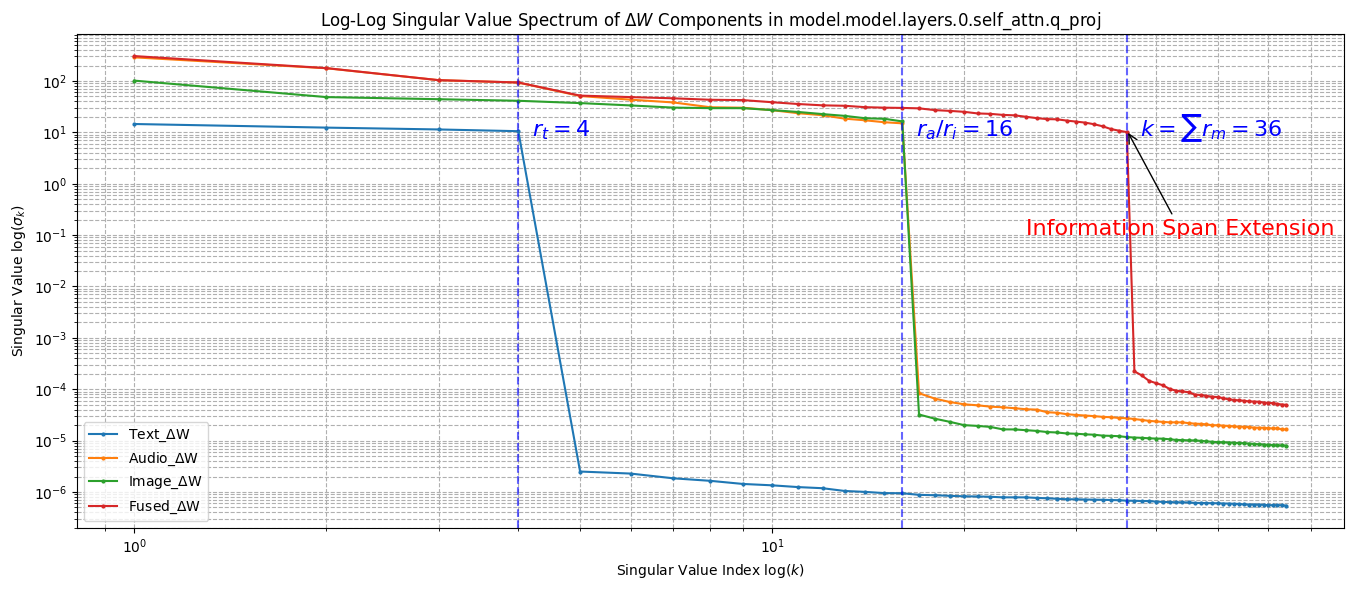

In [ ]:
from analysis import analyze_mslora_modality_correlation, analyze_svd_of_lora_weights

# 1. Correlation analysis
analyze_mslora_modality_correlation(model, test_loader, device, num_batches=5)

# 2. SVD 
lora_index = 0
analyze_svd_of_lora_weights(model, lora_index=lora_index, num_singular_values=64, output_dir=args.save_path)